MessageError: Error: credential propagation was unsuccessful

In [ ]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
  inflating: dataset/content0.json   
  inflating: dataset/content1.json   
  inflating: dataset/content10.json  
  inflating: dataset/content100.json  
  inflating: dataset/content101.json  
  inflating: dataset/content102.json  
  inflating: dataset/content103.json  
  inflating: dataset/content104.json  
  inflating: dataset/content105.json  
  inflating: dataset/content106.json  
  inflating: dataset/content107.json  
  inflating: dataset/content108.json  
  inflating: dataset/content109.json  
  inflating: dataset/content11.json  
  inflating: dataset/content110.json  
  inflating: dataset/content111.json  
  inflating: dataset/content112.json  
  inflating: dataset/content113.json  
  inflating: dataset/content114.json  
  inflating: dataset/content115.json  
  inflating: dataset/content116.json  
  inflating: dataset/content117.json  
  inflating: dataset/content118.json  
  inflating: dataset/content119.json  
  inflating: dataset/con

In [ ]:
!pip install transformers
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.2/255.2 kB 3.9 MB/s eta 0:00:00


In [ ]:
import os
import json
import pandas as pd

# Set the path to the folder containing the JSON files
#json_folder_path = '/content/drive/MyDrive/dataset'  # Adjust this path accordingly
json_folder_path='./dataset'
# List to hold data
data = []

# Load each JSON file into the list
for json_file in os.listdir(json_folder_path):
    if json_file.endswith('.json'):
        with open(os.path.join(json_folder_path, json_file)) as f:
            data.append(json.load(f))

# Convert the list of dictionaries into a DataFrame
df = pd.DataFrame(data)

# Display the first few rows of the DataFrame
print(df.head())

                                     Invention Title Publication Number  \
0  OPTIMIZING MACHINE LEARNING WORKLOAD TASK SCHE...            09/2024   
1  GESTURE-CONTROLLED ASSISTIVE DEVICE FOR PHYSIC...            10/2024   
2    A SYSTEM FOR MEASURING THE APICAL FORAMEN WIDTH            08/2024   
3  N-(3-FLUORO-[1,1'-BIPHENYL]-4-YL)-2-(PIPERAZIN...            06/2024   
4  SWAYAM BANKING: A COMPLETE AUTOMATED BANKING S...            05/2024   

  Publication Date Publication Type Application Number  \
0       01/03/2024              INA       202441007498   
1       08/03/2024              INA       202441007888   
2       23/02/2024              INA       202441002613   
3       09/02/2024              INA       202441002397   
4       02/02/2024              INA       202441000622   

  Application Filing Date Priority Number Priority Country Priority Date  \
0              03/02/2024                                                  
1              06/02/2024                       

With stopwords


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Define a simple preprocessing function
def preprocess(text):
    if isinstance(text, str):
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word.isalpha() and word.lower() not in stop_words]
        return ' '.join(tokens)
    return ""

# Apply preprocessing to the necessary columns (adjust these column names as needed)
df['cleaned_abstract'] = df['Abstract']#.apply(preprocess)
df['cleaned_specification'] = df['Complete Specification']#.apply(preprocess)

# Combine the cleaned text columns for embedding
texts = df['cleaned_abstract'].tolist()# + df['cleaned_specification'].tolist()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
len(texts)

1000

In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(texts, show_progress_bar=True)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(1000, 384)

Base logistic regression Run

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

                              0.00      0.00      0.00         2
          BIO-CHEMISTRY       0.00      0.00      0.00        10
BIO-MEDICAL ENGINEERING       0.85      0.48      0.61        48
          BIOTECHNOLOGY       0.64      0.41      0.50        22
               CHEMICAL       0.53      0.71      0.60        55
                  CIVIL       0.00      0.00      0.00         7
          COMMUNICATION       0.50      0.09      0.15        11
       COMPUTER SCIENCE       0.57      0.85      0.68       107
             ELECTRICAL       0.79      0.56      0.65        27
            ELECTRONICS       0.33      0.26      0.29        39
                   FOOD       0.00      0.00      0.00         4
MECHANICAL  ENGINEERING       0.42      0.67      0.52        45
             METALLURGY       0.00      0.00      0.00         3
                PHYSICS       0.50      0.17      0.25        12
     POLYMER TECHNOLOGY 

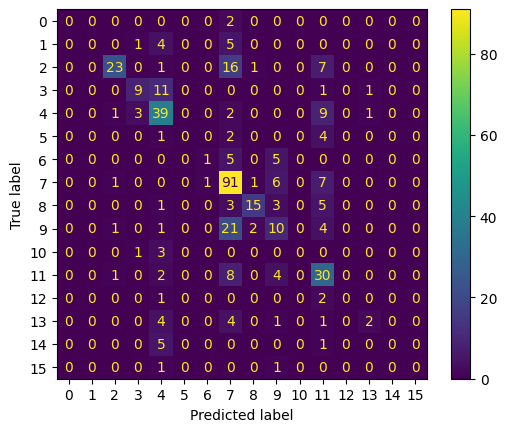

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt

# Prepare labels (assuming you have a label column)
labels = df['Field Of Invention'].tolist()  # Replace with your actual label column

# Split the embeddings into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.4, random_state=42)

# Initialize and train the Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
confusion_matrix = confusion_matrix(y_test,y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

Running SVM

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of embeddings: 1000
Number of labels: 1000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

                              0.00      0.00      0.00         1
          BIO-CHEMISTRY       0.00      0.00      0.00         7
BIO-MEDICAL ENGINEERING       0.78      0.62      0.69        34
          BIOTECHNOLOGY       0.64      0.47      0.54        15
               CHEMICAL       0.58      0.77      0.66        43
                  CIVIL       0.00      0.00      0.00         6
          COMMUNICATION       0.50      0.11      0.18         9
       COMPUTER SCIENCE       0.58      0.84      0.69        79
             ELECTRICAL       0.74      0.67      0.70        21
            ELECTRONICS       0.32      0.19      0.24        31
                   FOOD       0.00      0.00      0.00         3
MECHANICAL  ENGINEERING       0.39      0.59      0.47        34
             METALLURGY       0.00      0.00      0.00         2
                PHYSICS       1.00      0.11      0.20         9
     POLYMER TECHNOLOGY 

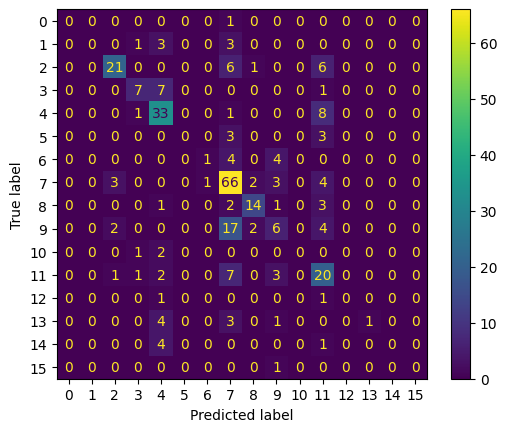

In [ ]:
import os
import json
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Ensure nltk data is available
nltk.download('punkt')
nltk.download('stopwords')

# Load your DataFrame (adjust the path to your JSON file)
'''json_folder_path = '/content/drive/MyDrive/dataset'  # Adjust this path accordingly
data = []
for json_file in os.listdir(json_folder_path):
    if json_file.endswith('.json'):
        with open(os.path.join(json_folder_path, json_file)) as f:
            data.append(json.load(f))

df = pd.DataFrame(data)

# Clean up column names
df.columns = df.columns.str.strip()

# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess(text):
    if isinstance(text, str):
        tokens = nltk.word_tokenize(text)
        return ' '.join([word for word in tokens if word.isalpha() and word.lower() not in stop_words])
    return ""

'''

# Apply preprocessing to necessary columns
#df['cleaned_abstract'] = df['Abstract']#.apply(preprocess)
#df['cleaned_specification'] = df['Complete Specification']#.apply(preprocess)

# Combine cleaned text columns for embeddings
#df['combined_text'] = df['cleaned_abstract'] #+ " " + df['cleaned_specification']
#texts = df['combined_text'].tolist()

# Load Sentence Transformer model
#model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
#embeddings = model.encode(texts, show_progress_bar=True)

# Prepare labels
#labels = df['Field Of Invention'].tolist()  # Ensure this corresponds to the rows used for embeddings

# Check lengths
print(f"Number of embeddings: {len(embeddings)}")
print(f"Number of labels: {len(labels)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.3, random_state=42)

# Initialize and train the SVM model
svm_model = SVC(kernel='rbf')  # You can change the kernel as needed
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)
#print(y_test)
y_pred = y_pred.tolist()
# Evaluate the model
print(classification_report(y_test, y_pred))
confusion_matrix = confusion_matrix(y_test,y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [ ]:
svm

Runnning KNN

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare labels (adjust this if necessary)
labels = df['Field Of Invention'].tolist()  # Ensure the correct label column is used

# Split embeddings and labels into training and test sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.3, random_state=42)


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune the 'n_neighbors' parameter

# Train the KNN model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))


from sklearn.model_selection import GridSearchCV

# Define a parameter grid for tuning
param_grid = {'n_neighbors': [3, 5, 7, 10]}

# Set up GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Perform grid search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model on the test set
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
print(classification_report(y_test, y_pred))


                         precision    recall  f1-score   support

                              0.00      0.00      0.00         1
          BIO-CHEMISTRY       0.00      0.00      0.00         5
BIO-MEDICAL ENGINEERING       0.44      0.62      0.51        29
          BIOTECHNOLOGY       0.27      0.41      0.33        17
               CHEMICAL       0.49      0.52      0.51        44
                  CIVIL       0.00      0.00      0.00         4
          COMMUNICATION       0.80      0.50      0.62         8
       COMPUTER SCIENCE       0.60      0.78      0.68        77
             ELECTRICAL       0.48      0.77      0.59        13
            ELECTRONICS       0.35      0.23      0.28        26
                   FOOD       0.00      0.00      0.00         8
MECHANICAL  ENGINEERING       0.53      0.46      0.49        37
             METALLURGY       0.00      0.00      0.00         1
                PHYSICS       0.67      0.08      0.15        24
     POLYMER TECHNOLOGY 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Without stopwords removed SVM

In [ ]:
# Combine 'Abstract' and 'Complete Specification' columns
df['combined_text'] = df['Abstract'].fillna('') + ' ' + df['Complete Specification'].fillna('')

# Convert combined text to a list
texts = df['combined_text'].tolist()

# Prepare the labels (assuming 'Field Of Invention' is the label column)
labels = df['Field Of Invention'].tolist()

# Check the number of samples and labels
print(f"Number of samples: {len(texts)}, Number of labels: {len(labels)}")

from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the combined text
embeddings = model.encode(texts, show_progress_bar=True)

# Check the shape of the generated embeddings
print(f"Embeddings shape: {embeddings.shape}")

from sklearn.model_selection import train_test_split

# Split the embeddings and labels into training and test sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.3, random_state=42)

# Check the number of samples in each set
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Initialize the SVM model (using linear kernel)
svm_model = SVC(kernel='linear')

# Train the SVM model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Number of samples: 1000, Number of labels: 1000


/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

...

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings shape: (1000, 384)
Training samples: 700, Test samples: 300
SVM Classification Report:
                         precision    recall  f1-score   support

                              0.00      0.00      0.00         1
          BIO-CHEMISTRY       0.00      0.00      0.00         5
BIO-MEDICAL ENGINEERING       0.55      0.59      0.57        29
          BIOTECHNOLOGY       0.38      0.65      0.48        17
               CHEMICAL       0.51      0.50      0.51        44
                  CIVIL       0.00      0.00      0.00         4
          COMMUNICATION       0.33      0.12      0.18         8
       COMPUTER SCIENCE       0.62      0.79      0.69        77
             ELECTRICAL       0.60      0.69      0.64        13
            ELECTRONICS       0.23      0.27      0.25        26
                   FOOD       0.00      0.00      0.00         8
MECHANICAL  ENGINEERING       0.49      0.62      0.55        37
             METALLURGY       0.00      0.00      0.00  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Trying XGBoost

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# ... (your existing code) ...
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': len(set(labels)),  # Number of unique classes
    'max_depth': 6,
    'eta': 0.3,
    'eval_metric': 'mlogloss'
}

# Train the XGBoost model

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)  # Use the same encoder for consistency

# Convert the data into DMatrix, now with encoded labels
dtrain = xgb.DMatrix(X_train, label=y_train_encoded)
dtest = xgb.DMatrix(X_test, label=y_test_encoded)

# ... (rest of your XGBoost code) ...
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': len(set(labels)),  # Number of unique classes
    'max_depth': 6,
    'eta': 0.3,
    'eval_metric': 'mlogloss'
}

# Train the XGBoost model
xgb_model = xgb.train(params, dtrain, num_boost_round=50)

# Make predictions
y_pred_xgb = xgb_model.predict(dtest)
y_pred_xgb = y_pred_xgb.astype(int) # Convert to integers



# After prediction, you might need to decode the predicted labels back to their original form:
y_pred_decoded = label_encoder.inverse_transform(y_pred_xgb)

# ... (rest of your code) ...
# Evaluate the XGBoost model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_decoded))

XGBoost Classification Report:
                         precision    recall  f1-score   support

                              0.00      0.00      0.00         1
          BIO-CHEMISTRY       0.00      0.00      0.00         5
BIO-MEDICAL ENGINEERING       0.38      0.34      0.36        29
          BIOTECHNOLOGY       0.42      0.65      0.51        17
               CHEMICAL       0.69      0.57      0.62        44
                  CIVIL       0.00      0.00      0.00         4
          COMMUNICATION       0.50      0.50      0.50         8
       COMPUTER SCIENCE       0.54      0.77      0.63        77
             ELECTRICAL       0.53      0.62      0.57        13
            ELECTRONICS       0.19      0.19      0.19        26
                   FOOD       0.50      0.12      0.20         8
MECHANICAL  ENGINEERING       0.43      0.54      0.48        37
             METALLURGY       0.00      0.00      0.00         1
                PHYSICS       0.50      0.04      0.08    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fine Tuning SVM Hyperparameters

In [ ]:
df['combined_text'] = df['Abstract'].fillna('') + ' ' + df['Complete Specification'].fillna('')
df['combined_text'] = df['combined_text'].str.replace(r'\W', ' ')  # Remove non-word characters
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# Set up GridSearchCV
grid_search_svm = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train, y_train)

# Output the best parameters and evaluate on the test set
print(f"Best Parameters: {grid_search_svm.best_params_}")
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

# Evaluate the tuned SVM model
from sklearn.metrics import classification_report
print("Tuned SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))







/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Tuned SVM Classification Report:
                         precision    recall  f1-score   support

                              0.00      0.00      0.00         1
          BIO-CHEMISTRY       0.00      0.00      0.00         5
BIO-MEDICAL ENGINEERING       0.61      0.66      0.63        29
          BIOTECHNOLOGY       0.38      0.65      0.48        17
               CHEMICAL       0.55      0.52      0.53        44
                  CIVIL       0.00      0.00      0.00         4
          COMMUNICATION       0.50      0.50      0.50         8
       COMPUTER SCIENCE       0.63      0.78      0.70        77
             ELECTRICAL       0.60      0.69      0.64        13
            ELECTRONICS       0.23      0.27      0.25        26
                   FOOD       0.00      0.00      0.00         8
MECHANICAL  ENGINEERING       0.48      0.57      0.52        37
             METALLURGY       0.00      0.00      0.00         1


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fine-tuning hyperparameters for XGBoost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()

# Fit the encoder to your labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define parameter grid for XGBoost
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize XGBoost and use RandomizedSearchCV
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(set(labels)))
pipeline = Pipeline([
    ('label_encoder', label_encoder),  # Add label encoder to pipeline
    ('xgb', xgb_model)
])
grid_search_xgb = RandomizedSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, n_iter=10)
grid_search_xgb.fit(X_train, y_train)

# Output the best parameters and evaluate on the test set
print(f"Best Parameters: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_encoded = best_xgb.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

y_pred_xgb = best_xgb.predict(X_test)

# Evaluate the tuned XGBoost model
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb_encoded))

# XGBoost cross-validation
xgb_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost Cross-Validation Accuracy: {xgb_scores.mean():.4f}")

from sklearn.model_selection import cross_val_score

# SVM cross-validation
svm_scores = cross_val_score(best_svm, X_train, y_train, cv=5, scoring='accuracy')
print(f"SVM Cross-Validation Accuracy: {svm_scores.mean():.4f}")

from sklearn.ensemble import VotingClassifier

# Create a voting classifier with both SVM and XGBoost
voting_clf = VotingClassifier(estimators=[
    ('svm', best_svm)
], voting='soft')

# Train the ensemble model
voting_clf.fit(X_train, y_train)

# Evaluate the ensemble model
y_pred_ensemble = voting_clf.predict(X_test)
print("Ensemble Model Classification Report:")
print(classification_report(y_test, y_pred_ensemble))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py", line 1491, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15], got ['' 'BIO-CHEMISTRY' 'BIO-MEDICAL ENGINEERING' 'BIOTECHNOLOGY' 'CHEMICAL'
 'CIVIL' 'COMMUNICATION' 'COMPUTER SCIENCE' 'ELECTRICAL